# Задание 1.2 - Линейный классификатор (Linear classifier)

В этом задании мы реализуем другую модель машинного обучения - линейный классификатор. Линейный классификатор подбирает для каждого класса веса, на которые нужно умножить значение каждого признака и потом сложить вместе.
Тот класс, у которого эта сумма больше, и является предсказанием модели.

В этом задании вы:
- потренируетесь считать градиенты различных многомерных функций
- реализуете подсчет градиентов через линейную модель и функцию потерь softmax
- реализуете процесс тренировки линейного классификатора
- подберете параметры тренировки на практике

На всякий случай, еще раз ссылка на туториал по numpy:  
http://cs231n.github.io/python-numpy-tutorial/

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_gradient
from metrics import multiclass_accuracy 
import linear_classifer

# Как всегда, первым делом загружаем данные

Мы будем использовать все тот же SVHN.

In [3]:
def prepare_for_linear_classifier(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(float) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(float) / 255.0
    
    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image
    
    # Add another channel with ones as a bias term
    train_flat_with_ones = np.hstack([train_flat, np.ones((train_X.shape[0], 1))])
    test_flat_with_ones = np.hstack([test_flat, np.ones((test_X.shape[0], 1))])    
    return train_flat_with_ones, test_flat_with_ones
    
train_X, train_y, test_X, test_y = load_svhn("data", max_train=10000, max_test=1000)    
train_X, test_X = prepare_for_linear_classifier(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Играемся с градиентами!

В этом курсе мы будем писать много функций, которые вычисляют градиенты аналитическим методом.

Все функции, в которых мы будем вычислять градиенты, будут написаны по одной и той же схеме.  
Они будут получать на вход точку, где нужно вычислить значение и градиент функции, а на выходе будут выдавать кортеж (tuple) из двух значений - собственно значения функции в этой точке (всегда одно число) и аналитического значения градиента в той же точке (той же размерности, что и вход).
```
def f(x):
    """
    Computes function and analytic gradient at x
    
    x: np array of float, input to the function
    
    Returns:
    value: float, value of the function 
    grad: np array of float, same shape as x
    """
    ...
    
    return value, grad
```

Необходимым инструментом во время реализации кода, вычисляющего градиенты, является функция его проверки. Эта функция вычисляет градиент численным методом и сверяет результат с градиентом, вычисленным аналитическим методом.

Мы начнем с того, чтобы реализовать вычисление численного градиента (numeric gradient) в функции `check_gradient` в `gradient_check.py`. Эта функция будет принимать на вход функции формата, заданного выше, использовать значение `value` для вычисления численного градиента и сравнит его с аналитическим - они должны сходиться.

Напишите часть функции, которая вычисляет градиент с помощью численной производной для каждой координаты. Для вычисления производной используйте так называемую two-point formula (https://en.wikipedia.org/wiki/Numerical_differentiation):

![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/22fc2c0a66c63560a349604f8b6b39221566236d)

Все функции приведенные в следующей клетке должны проходить gradient check.

In [4]:
# TODO: Implement check_gradient function in gradient_check.py
# All the functions below should pass the gradient check

def square(x):
    return x[0] * x[0], 2*x

check_gradient(square, np.array([3.0]))

def array_sum(x):
    assert x.shape == (2,), x.shape
    return np.sum(x), np.ones_like(x)

check_gradient(array_sum, np.array([3.0, 2.0]))

def array_2d_sum(x):
    assert x.shape == (2,2)
    return np.sum(x), np.ones_like(x)

check_gradient(array_2d_sum, np.array([[3.0, 2.0], [1.0, 0.0]]))

Gradient check passed!
Gradient check passed!
Gradient check passed!


True

## Начинаем писать свои функции, считающие аналитический градиент

Теперь реализуем функцию softmax, которая получает на вход оценки для каждого класса и преобразует их в вероятности от 0 до 1:
![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/e348290cf48ddbb6e9a6ef4e39363568b67c09d3)

**Важно:** Практический аспект вычисления этой функции заключается в том, что в ней учавствует вычисление экспоненты от потенциально очень больших чисел - это может привести к очень большим значениям в числителе и знаменателе за пределами диапазона float.

К счастью, у этой проблемы есть простое решение -- перед вычислением softmax вычесть из всех оценок максимальное значение среди всех оценок:
```
predictions -= np.max(predictions)
```
(подробнее здесь - http://cs231n.github.io/linear-classify/#softmax, секция `Practical issues: Numeric stability`)

In [5]:
# TODO Implement softmax and cross-entropy for single sample
probs = linear_classifer.softmax(np.array([-10, 0, 10]))

# Make sure it works for big numbers too!
probs = linear_classifer.softmax(np.array([1000, 0, 0]))
assert np.isclose(probs[0], 1.0)

Кроме этого, мы реализуем cross-entropy loss, которую мы будем использовать как функцию ошибки (error function).
В общем виде cross-entropy определена следующим образом:
![image](https://wikimedia.org/api/rest_v1/media/math/render/svg/0cb6da032ab424eefdca0884cd4113fe578f4293)

где x - все классы, p(x) - истинная вероятность принадлежности сэмпла классу x, а q(x) - вероятность принадлежности классу x, предсказанная моделью.  
В нашем случае сэмпл принадлежит только одному классу, индекс которого передается функции. Для него p(x) равна 1, а для остальных классов - 0. 

Это позволяет реализовать функцию проще!

In [6]:
probs = linear_classifer.softmax(np.array([-5, 0, 5]))
linear_classifer.cross_entropy_loss(probs, 1)

np.float64(5.006760443547122)

После того как мы реализовали сами функции, мы можем реализовать градиент.

Оказывается, что вычисление градиента становится гораздо проще, если объединить эти функции в одну, которая сначала вычисляет вероятности через softmax, а потом использует их для вычисления функции ошибки через cross-entropy loss.

Эта функция `softmax_with_cross_entropy` будет возвращает и значение ошибки, и градиент по входным параметрам. Мы проверим корректность реализации с помощью `check_gradient`.

In [7]:
# TODO Implement combined function or softmax and cross entropy and produces gradient
loss, grad = linear_classifer.softmax_with_cross_entropy(np.array([1, 0, 0]), 1)
check_gradient(lambda x: linear_classifer.softmax_with_cross_entropy(x, 1), np.array([1, 0, 0], float))

Gradient check passed!


True

В качестве метода тренировки мы будем использовать стохастический градиентный спуск (stochastic gradient descent или SGD), который работает с батчами сэмплов. 

Поэтому все наши фукнции будут получать не один пример, а батч, то есть входом будет не вектор из `num_classes` оценок, а матрица размерности `batch_size, num_classes`. Индекс примера в батче всегда будет первым измерением.

Следующий шаг - переписать наши функции так, чтобы они поддерживали батчи.

Финальное значение функции ошибки должно остаться числом, и оно равно среднему значению ошибки среди всех примеров в батче.

In [8]:
# TODO Extend combined function so it can receive a 2d array with batch of samples
np.random.seed(42)
# Test batch_size = 1
num_classes = 4
batch_size = 1
predictions = np.random.randint(-1, 3, size=(batch_size, num_classes)).astype(float)
target_index = np.random.randint(0, num_classes, size=(batch_size, 1)).astype(int)
check_gradient(lambda x: linear_classifer.softmax_with_cross_entropy(x, target_index), predictions)

# Test batch_size = 3
num_classes = 4
batch_size = 3
predictions = np.random.randint(-1, 3, size=(batch_size, num_classes)).astype(float)
target_index = np.random.randint(0, num_classes, size=(batch_size, 1)).astype(int)
check_gradient(lambda x: linear_classifer.softmax_with_cross_entropy(x, target_index), predictions)

# Make sure maximum subtraction for numberic stability is done separately for every sample in the batch
probs = linear_classifer.softmax(np.array([[20,0,0], [1000, 0, 0]]))
assert np.all(np.isclose(probs[:, 0], 1.0))

Gradient check passed!
Gradients are different at (0, 2). Analytic: -0.32202, Numeric: -0.09980


### Наконец, реализуем сам линейный классификатор!

softmax и cross-entropy получают на вход оценки, которые выдает линейный классификатор.

Он делает это очень просто: для каждого класса есть набор весов, на которые надо умножить пиксели картинки и сложить. Получившееся число и является оценкой класса, идущей на вход softmax.

Таким образом, линейный классификатор можно представить как умножение вектора с пикселями на матрицу W размера `num_features, num_classes`. Такой подход легко расширяется на случай батча векторов с пикселями X размера `batch_size, num_features`:

`predictions = X * W`, где `*` - матричное умножение.

Реализуйте функцию подсчета линейного классификатора и градиентов по весам `linear_softmax` в файле `linear_classifer.py`

In [9]:
# TODO Implement linear_softmax function that uses softmax with cross-entropy for linear classifier
batch_size = 2
num_classes = 2
num_features = 3
np.random.seed(42)
W = np.random.randint(-1, 3, size=(num_features, num_classes)).astype(float)
X = np.random.randint(-1, 3, size=(batch_size, num_features)).astype(float)
target_index = np.ones(batch_size, dtype=int)

loss, dW = linear_classifer.linear_softmax(X, W, target_index)
check_gradient(lambda w: linear_classifer.linear_softmax(X, w, target_index), W)

Gradient check passed!


True

### И теперь регуляризация

Мы будем использовать L2 regularization для весов как часть общей функции ошибки.

Напомним, L2 regularization определяется как

l2_reg_loss = regularization_strength * sum<sub>ij</sub> W[i, j]<sup>2</sup>

Реализуйте функцию для его вычисления и вычисления соотвествующих градиентов.

In [10]:
# TODO Implement l2_regularization function that implements loss for L2 regularization
linear_classifer.l2_regularization(W, 0.01)
check_gradient(lambda w: linear_classifer.l2_regularization(w, 0.01), W)

Gradient check passed!


True

# Тренировка!

Градиенты в порядке, реализуем процесс тренировки!

In [15]:
# TODO: Implement LinearSoftmaxClassifier.fit function
classifier = linear_classifer.LinearSoftmaxClassifier()
loss_history = classifier.fit(train_X, train_y, epochs=1000, learning_rate=1e-3, batch_size=300, reg=1e1)

Epoch 0, loss: 2.301636
Epoch 1, loss: 2.301216
Epoch 2, loss: 2.301749
Epoch 3, loss: 2.301346
Epoch 4, loss: 2.301615
Epoch 5, loss: 2.301379
Epoch 6, loss: 2.300624
Epoch 7, loss: 2.301946
Epoch 8, loss: 2.300757
Epoch 9, loss: 2.300671
Epoch 10, loss: 2.301084
Epoch 11, loss: 2.301523
Epoch 12, loss: 2.301239
Epoch 13, loss: 2.301188
Epoch 14, loss: 2.300826
Epoch 15, loss: 2.301141
Epoch 16, loss: 2.301599
Epoch 17, loss: 2.300007
Epoch 18, loss: 2.301304
Epoch 19, loss: 2.300643
Epoch 20, loss: 2.301021
Epoch 21, loss: 2.300447
Epoch 22, loss: 2.300848
Epoch 23, loss: 2.300445
Epoch 24, loss: 2.302124
Epoch 25, loss: 2.301550
Epoch 26, loss: 2.300152
Epoch 27, loss: 2.300721
Epoch 28, loss: 2.302158
Epoch 29, loss: 2.301517
Epoch 30, loss: 2.300232
Epoch 31, loss: 2.301821
Epoch 32, loss: 2.301823
Epoch 33, loss: 2.301145
Epoch 34, loss: 2.301223
Epoch 35, loss: 2.301308
Epoch 36, loss: 2.301086
Epoch 37, loss: 2.301779
Epoch 38, loss: 2.300698
Epoch 39, loss: 2.300656
Epoch 40, 

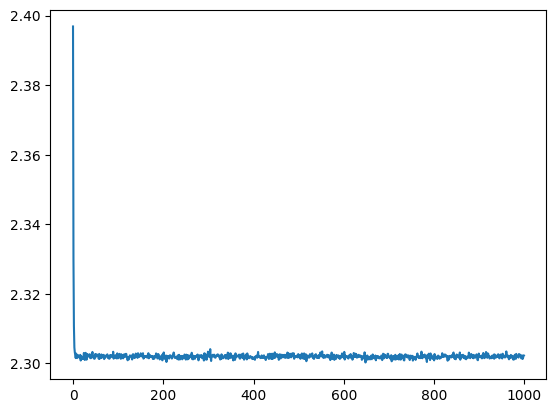

In [16]:
# let's look at the loss history!
plt.plot(loss_history)

In [17]:
# Let's check how it performs on validation set
pred = classifier.predict(val_X)
accuracy = multiclass_accuracy(pred, val_y)
print("Accuracy: ", accuracy)

# Now, let's train more and see if it performs better
classifier.fit(train_X, train_y, epochs=100, learning_rate=1e-3, batch_size=300, reg=1e1)
pred = classifier.predict(val_X)
accuracy = multiclass_accuracy(pred, val_y)
print("Accuracy after training for 100 epochs: ", accuracy)

Accuracy:  0.129
Epoch 0, loss: 2.300761
Epoch 1, loss: 2.300481
Epoch 2, loss: 2.301082
Epoch 3, loss: 2.301706
Epoch 4, loss: 2.300094
Epoch 5, loss: 2.301000
Epoch 6, loss: 2.300327
Epoch 7, loss: 2.300800
Epoch 8, loss: 2.301393
Epoch 9, loss: 2.301634
Epoch 10, loss: 2.301530
Epoch 11, loss: 2.300620
Epoch 12, loss: 2.301636
Epoch 13, loss: 2.300436
Epoch 14, loss: 2.301241
Epoch 15, loss: 2.300957
Epoch 16, loss: 2.301113
Epoch 17, loss: 2.301096
Epoch 18, loss: 2.300427
Epoch 19, loss: 2.300712
Epoch 20, loss: 2.301516
Epoch 21, loss: 2.301781
Epoch 22, loss: 2.300683
Epoch 23, loss: 2.300930
Epoch 24, loss: 2.300815
Epoch 25, loss: 2.302452
Epoch 26, loss: 2.300383
Epoch 27, loss: 2.301891
Epoch 28, loss: 2.301518
Epoch 29, loss: 2.300899
Epoch 30, loss: 2.300543
Epoch 31, loss: 2.301158
Epoch 32, loss: 2.300846
Epoch 33, loss: 2.300151
Epoch 34, loss: 2.301584
Epoch 35, loss: 2.300852
Epoch 36, loss: 2.301199
Epoch 37, loss: 2.301762
Epoch 38, loss: 2.301586
Epoch 39, loss: 2.

### Как и раньше, используем кросс-валидацию для подбора гиперпараметтов.

В этот раз, чтобы тренировка занимала разумное время, мы будем использовать только одно разделение на тренировочные (training) и проверочные (validation) данные.

Теперь нам нужно подобрать не один, а два гиперпараметра! Не ограничивайте себя изначальными значениями в коде.  
Добейтесь точности более чем **20%** на проверочных данных (validation data).

In [21]:
search_epochs = 20
final_epochs = 200
batch_size = 300

learning_rates = [1e-2, 5e-3, 1e-3]
reg_strengths = [1e-1, 1e-2, 1e-3]

best_classifier = None
best_val_accuracy = -1
best_lr = None
best_reg = None
results = {}

for learning_rate in learning_rates:
    for reg in reg_strengths:
        model = linear_classifer.LinearSoftmaxClassifier()
        model.fit(
            train_X,
            train_y,
            batch_size=batch_size,
            learning_rate=learning_rate,
            reg=reg,
            epochs=search_epochs
        )

        pred = model.predict(val_X)
        accuracy = multiclass_accuracy(pred, val_y)
        results[(learning_rate, reg)] = accuracy

        if accuracy > best_val_accuracy:
            best_val_accuracy = accuracy
            best_lr = learning_rate
            best_reg = reg

print('best validation accuracy achieved: %f' % best_val_accuracy)
print('best learning rate:', best_lr)
print('best reg strength:', best_reg)

best_classifier = linear_classifer.LinearSoftmaxClassifier()
best_classifier.fit(
    train_X,
    train_y,
    batch_size=batch_size,
    learning_rate=best_lr,
    reg=best_reg,
    epochs=final_epochs
)


Epoch 0, loss: 2.297965
Epoch 1, loss: 2.296894
Epoch 2, loss: 2.285475
Epoch 3, loss: 2.279099
Epoch 4, loss: 2.289313
Epoch 5, loss: 2.273344
Epoch 6, loss: 2.263388
Epoch 7, loss: 2.268868
Epoch 8, loss: 2.272278
Epoch 9, loss: 2.254904
Epoch 10, loss: 2.253467
Epoch 11, loss: 2.252529
Epoch 12, loss: 2.255485
Epoch 13, loss: 2.248231
Epoch 14, loss: 2.265371
Epoch 15, loss: 2.248456
Epoch 16, loss: 2.258359
Epoch 17, loss: 2.240374
Epoch 18, loss: 2.251551
Epoch 19, loss: 2.268227
Epoch 0, loss: 2.294488
Epoch 1, loss: 2.284644
Epoch 2, loss: 2.274156
Epoch 3, loss: 2.273203
Epoch 4, loss: 2.273598
Epoch 5, loss: 2.271715
Epoch 6, loss: 2.269236
Epoch 7, loss: 2.254861
Epoch 8, loss: 2.268981
Epoch 9, loss: 2.247621
Epoch 10, loss: 2.256198
Epoch 11, loss: 2.237779
Epoch 12, loss: 2.239199
Epoch 13, loss: 2.241326
Epoch 14, loss: 2.221192
Epoch 15, loss: 2.187448
Epoch 16, loss: 2.236312
Epoch 17, loss: 2.215230
Epoch 18, loss: 2.203545
Epoch 19, loss: 2.197962
Epoch 0, loss: 2.295

[np.float64(2.29370971752656),
 np.float64(2.28973349958245),
 np.float64(2.2791795071318663),
 np.float64(2.2692265147008612),
 np.float64(2.2680252376838013),
 np.float64(2.266266798940916),
 np.float64(2.251778296964871),
 np.float64(2.2614097775616493),
 np.float64(2.232312696980287),
 np.float64(2.241856617931995),
 np.float64(2.2341696339310912),
 np.float64(2.231206213020095),
 np.float64(2.201560322764481),
 np.float64(2.235729893843372),
 np.float64(2.2198610604259073),
 np.float64(2.253935671716937),
 np.float64(2.1969037222954793),
 np.float64(2.2255130055198964),
 np.float64(2.2138137942180047),
 np.float64(2.209188043044011),
 np.float64(2.2064788061218903),
 np.float64(2.201369153591099),
 np.float64(2.185182973661803),
 np.float64(2.1865923010210886),
 np.float64(2.2104234892250365),
 np.float64(2.1638778035576394),
 np.float64(2.193127194200049),
 np.float64(2.21152548938494),
 np.float64(2.158788915497678),
 np.float64(2.199484780935903),
 np.float64(2.1821756832190475

# Какой же точности мы добились на тестовых данных?

In [23]:
print('best validation accuracy achieved: %f' % best_val_accuracy)
print('best learning rate:', best_lr)
print('best reg strength:', best_reg)

best validation accuracy achieved: 0.233000
best learning rate: 0.01
best reg strength: 0.001


In [22]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Linear softmax classifier test set accuracy: %f' % (test_accuracy, ))

Linear softmax classifier test set accuracy: 0.204000
